# TIME SERIES - Tương quan chuỗi thời gian: Cấu trúc ACF, PACF VÀ tính dừng

# Mục lục

* [1. Mục tiêu bài toán](#sec-1)
* [2. Hệ số Lag (Độ trễ)](#sec-2)
* [3. Phân biệt ACF và PACF](#sec-3)
    * [3.1 ACF (Autocorrelation Function - Tự tương quan)](#sec-3-1)
    * [3.2 PACF (Partial Autocorrelation Function - Tự tương quan riêng phần)](#sec-3-2)
    * [3.3 Ví dụ minh họa thực tế](#sec-3-3)
* [4. Giá trị của việc trực quan hóa ACF](#sec-4)
* [5. Chuỗi dừng và các mô hình dự báo (AR, MA, ARIMA)](#sec-5)
* [6. Phân tích và Nhận xét Đồ thị ACF & PACF (Biến Confirmed - US)](#sec-7)
    * [6.1. Số ca nhiễm/tử vong có phụ thuộc vào những ngày trước đó không?](#sec-7-1)
    * [6.2. Ảnh hưởng của quá khứ kéo dài trong bao lâu?](#sec-7-2)
    * [6.3. Chuỗi có tính chu kỳ theo tuần không?](#sec-7-3)
    * [6.4. Chuỗi dữ liệu COVID có dừng không?](#sec-7-4)
    * [6.5. Có cần sai phân để loại bỏ xu hướng không?](#sec-7-5)
    * [6.6. Có thể xác định bậc p, q từ ACF và PACF hiện tại không?](#sec-7-6)
    * [6.7. Chuỗi thời gian phù hợp với mô hình AR, MA hay ARIMA?](#sec-7-7)
    * [6.8. Có thể dự báo số ca nhiễm/tử vong trong tương lai dựa trên quá khứ không?](#sec-7-8)
    * [6.9. Có sự khác biệt cấu trúc tương quan giữa các quốc gia không?](#sec-7-9)
    * [6.10. Các đợt bùng dịch (waves) có thể được phát hiện qua ACF không?](#sec-7-10)
* [7. Tổng kết](#sec-8)


<a id="sec-1"></a>

# 1. Mục tiêu bài toán
* **Mục tiêu cốt lõi:** Phân tích cấu trúc tương quan để xây dựng mô hình **dự báo tương lai dựa trên dữ liệu quá khứ**.
* **Câu hỏi cần trả lời:** Giá trị của ngày hôm nay có bị phụ thuộc vào các ngày trước đó không? Và sự phụ thuộc đó kéo dài ngược về quá khứ bao nhiêu bước (bao nhiêu ngày)?
* **Tại sao phải vẽ ACF và PACF?** Các biểu đồ Time Plot (như ở phần trước) chỉ cho ta thấy xu hướng tổng thể. Mắt người không thể nhìn vào một đường cong mà biết được "số ca bệnh hôm nay lây từ 3 ngày trước hay 7 ngày trước". Biểu đồ ACF và PACF đóng vai trò như "máy chụp X-quang", giúp lượng hóa bằng toán học chính xác mức độ ảnh hưởng của quá khứ lên hiện tại.

<a id="sec-2"></a>

# 2. Hệ số Lag (Độ trễ)
* **Định nghĩa:** Hệ số Lag ($k$) là khoảng thời gian bị lùi lại (độ trễ) giữa hai mốc quan sát trong cùng một chuỗi thời gian.
* **Công thức toán học cơ bản:** Sự tương quan ở độ trễ $k$ được tính bằng hiệp phương sai giữa giá trị hiện tại $Y_t$ và giá trị trong quá khứ $Y_{t-k}$: $Cov(Y_t, Y_{t-k})$
* **Ý nghĩa:** Lag giúp ta đối chiếu chuỗi dữ liệu với chính "cái bóng" của nó trong quá khứ. Ví dụ ở Lag = 7, ta đang tìm kiếm quy luật lặp lại sau mỗi chu kỳ 1 tuần.

<a id="sec-3"></a>

# 3. Phân biệt ACF và PACF

<a id="sec-3-1"></a>

## 3.1 ACF (Autocorrelation Function - Tự tương quan)
* **Khái niệm:** Đo lường mức độ tương quan tuyến tính giữa $Y_t$ và $Y_{t-k}$.
* **Đặc tính:** Nó đo lường **TỔNG TÁC ĐỘNG** (Bao gồm cả tác động trực tiếp và tác động gián tiếp thông qua các mốc thời gian trung gian).

<a id="sec-3-2"></a>

## 3.2 PACF (Partial Autocorrelation Function - Tự tương quan riêng phần)
* **Khái niệm:** Cũng đo lường tương quan giữa $Y_t$ và $Y_{t-k}$, nhưng đã **loại bỏ (triệt tiêu) hoàn toàn nhiễu** từ các mốc thời gian nằm giữa $t$ và $t-k$.
* **Đặc tính:** Nó chỉ đo lường **TÁC ĐỘNG TRỰC TIẾP** và thuần túy nhất.

<a id="sec-3-3"></a>

## 3.3 Ví dụ minh họa thực tế
Giả sử ta phân tích sự lây lan Covid-19 trong 3 ngày liên tiếp: Ngày 1 truyền bệnh cho Ngày 2, Ngày 2 truyền bệnh cho Ngày 3.
* **Với ACF ở Lag 2 (Giữa Ngày 1 và Ngày 3):** Hệ số ACF sẽ rất cao. Máy tính hiểu rằng Ngày 1 có tác động tới Ngày 3 (dù là tác động gián tiếp qua "cầu nối" là Ngày 2).
* **Với PACF ở Lag 2:** PACF sẽ loại bỏ đi ảnh hưởng của "cầu nối" Ngày 2. Lúc này, PACF sẽ tụt về 0, chứng minh được bản chất thực sự: Ngày 1 không hề lây trực tiếp cho Ngày 3.

<a id="sec-4"></a>

# 4. Giá trị của việc trực quan hóa ACF
Sau khi vẽ được ACF, ta thu được các thông tin sống còn sau:
1. **Phát hiện tính mùa vụ (Seasonality):** Nếu các cột ACF nhô lên nhịp nhàng sau mỗi khoảng thời gian (VD: Lag 7, 14, 21), chuỗi chắc chắn có tính chu kỳ tuần.
2. **Kiểm tra tính dừng (Stationarity):** Nếu các vạch ACF giảm dần về 0 một cách vô cùng chậm chạp (bám riết lấy vạch trên), chuỗi đó có xu hướng (Trend) và chưa dừng.
3. **Tìm tham số mô hình:** Xác định được bậc $q$ cho mô hình Moving Average (MA).

<a id="sec-5"></a>

# 5. Chuỗi dừng và các mô hình dự báo (AR, MA, ARIMA)
* **Chuỗi dừng (Stationary Series) là gì?** Là chuỗi thời gian có các đặc trưng thống kê (Kỳ vọng/Mean và Phương sai/Variance) không bị thay đổi theo thời gian. Các mô hình Machine Learning cổ điển chỉ hoạt động chính xác trên chuỗi dừng. Nếu chuỗi có Trend (như số ca Covid tăng liên tục), ta phải lấy sai phân (Differencing) để triệt tiêu Trend, ép nó thành chuỗi dừng.
* **Mô hình AR (AutoRegressive):** Tự hồi quy. Dự báo tương lai bằng sự kết hợp tuyến tính của $p$ giá trị trong quá khứ. (Bậc $p$ nhìn từ biểu đồ **PACF**).
* **Mô hình MA (Moving Average):** Trung bình trượt. Dự báo tương lai dựa trên $q$ sai số dự báo trong quá khứ. (Bậc $q$ nhìn từ biểu đồ **ACF**).
* **Mô hình ARIMA (AutoRegressive Integrated Moving Average):** Là sự kết hợp của AR và MA, cộng thêm chữ "I" (Integrated - Bậc $d$). Bậc $d$ chính là số lần ta phải lấy sai phân để biến chuỗi Covid-19 từ không dừng thành chuỗi dừng.

[Time Series Mode] Đã nạp và sắp xếp dữ liệu theo 'Date'.
[EXECUTE] Đang vẽ biểu đồ ACF cho biến 'Confirmed' (Lag = 40)...


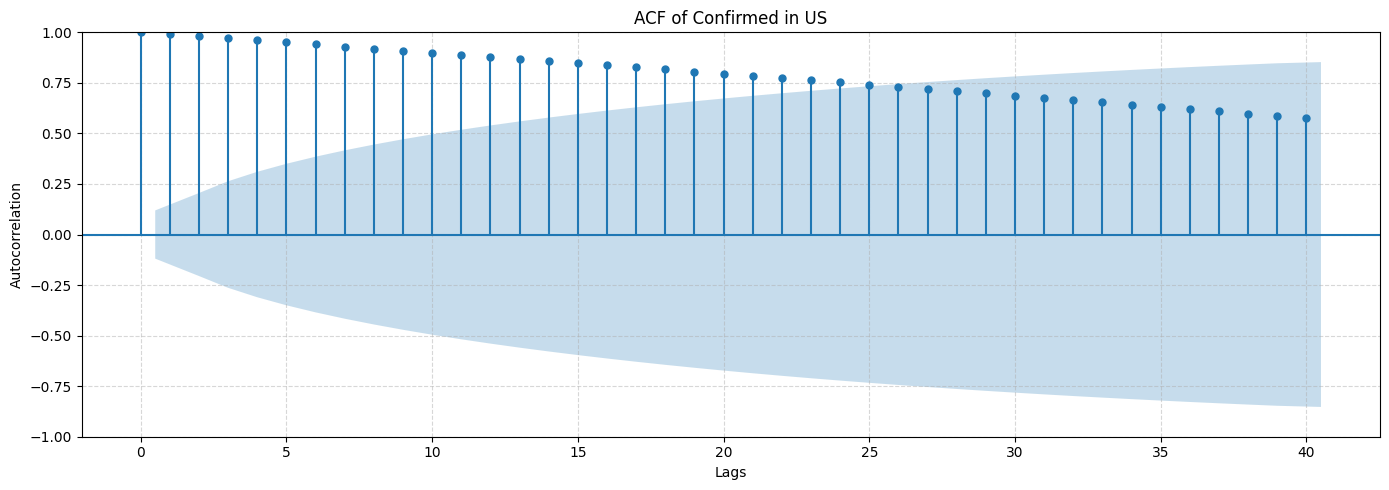

[EXECUTE] Đang vẽ biểu đồ PACF cho biến 'Confirmed' (Lag = 40)...


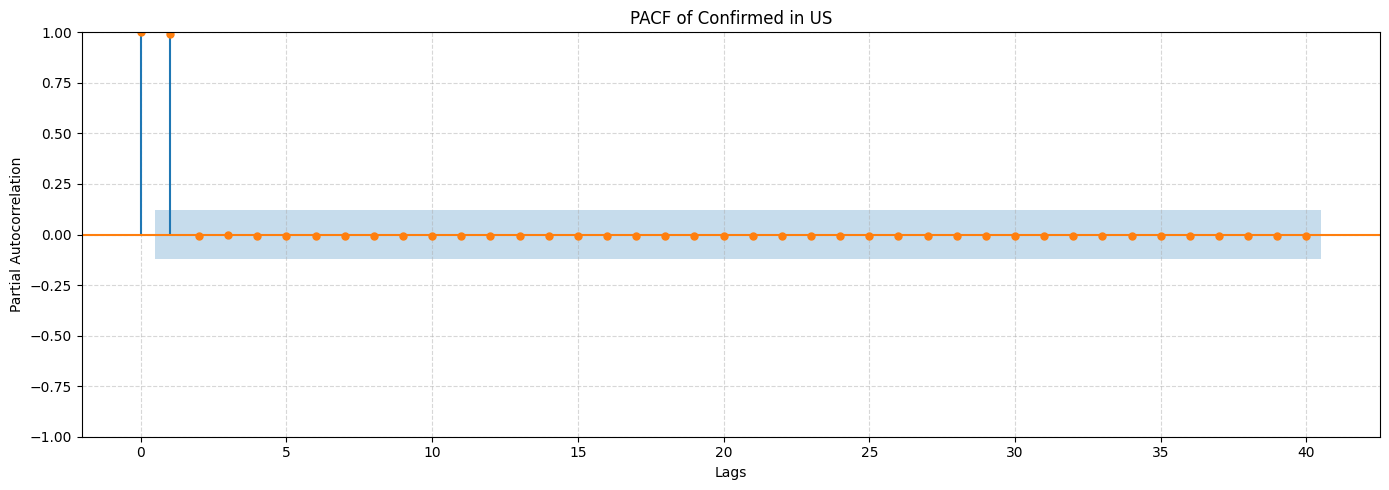

In [1]:
import os
import sys

for src_path in (os.path.abspath("../src"), os.path.abspath("src")):
    if os.path.isdir(src_path) and src_path not in sys.path:
        sys.path.append(src_path)

from time_series.dataset import TimeSeriesDataset
from time_series.analysis_correlation_structure import PACFAnalysisStructure

# Nạp dữ liệu
ts_data = TimeSeriesDataset(path="../data/time_series/time-series-19-covid-combined.csv", time_column="Date")

# --- 1. Vẽ ACF ---
# Tham số use_pacf=False (mặc định), khảo sát quá khứ n_lags=40 ngày
acf_analyzer = PACFAnalysisStructure(region="US", feature_name="Confirmed", use_pacf=False, n_lags=40)
acf_analyzer.run(ts_data)

# --- 2. Vẽ PACF ---
pacf_analyzer = PACFAnalysisStructure(region="US", feature_name="Confirmed", use_pacf=True, n_lags=40)
pacf_analyzer.run(ts_data)

<a id="sec-7"></a>

# 6. Phân tích và Nhận xét Đồ thị ACF & PACF (Biến Confirmed - US)

Dựa vào hai biểu đồ ACF và PACF vừa trực quan hóa, ta có thể giải đáp các câu hỏi quan trọng về cấu trúc tương quan của đại dịch Covid-19 tại Mỹ:

<a id="sec-7-1"></a>

## 6.1. Số ca nhiễm/tử vong có phụ thuộc vào những ngày trước đó không?
> **CÓ, phụ thuộc cực kỳ mạnh.** Cả đồ thị ACF và PACF đều cho thấy ở Lag 1, hệ số tương quan xấp xỉ 1.0. Số ca tích lũy của ngày hôm nay gần như được quyết định hoàn toàn bởi số lượng ca của ngày hôm qua.

<a id="sec-7-2"></a>

## 6.2. Ảnh hưởng của quá khứ kéo dài trong bao lâu?
> Nhìn vào **ACF**, ta thấy ảnh hưởng kéo dài rất lâu (qua mốc 40 ngày vẫn còn tương quan dương rất lớn > 0.5). Tuy nhiên, dựa vào đồ thị **PACF**: Ảnh hưởng trực tiếp chỉ kéo dài đúng **1 ngày (Lag 1)**. Từ Lag 2 trở đi, PACF tụt hẳn xuống vùng tin cậy (xấp xỉ 0). Nghĩa là, ngày cách đây 1 tháng có vẻ như liên quan đến hôm nay, nhưng thực chất nó chỉ truyền tác động dây chuyền qua từng ngày một.

<a id="sec-7-3"></a>

## 6.3. Chuỗi có tính chu kì theo tuần không?
> **KHÔNG.** Nếu có chu kỳ tuần, đồ thị ACF sẽ nhô cao lên theo hình lượn sóng cứ mỗi 7 ngày (Lag 7, 14, 21). Ở đây ACF chỉ giảm dần đều, chứng tỏ dữ liệu tích lũy không có các gợn sóng chu kỳ báo cáo hàng tuần.

<a id="sec-7-4"></a>

## 6.4. Chuỗi dữ liệu COVID có dừng không?
> **KHÔNG DỪNG.** Dấu hiệu của một chuỗi không dừng là đồ thị ACF giảm về 0 một cách vô cùng chậm chạp và không hề có dấu hiệu cắt xuống phần âm. Điều này tái khẳng định chuỗi chứa xu hướng (Trend) tăng liên tục.

<a id="sec-7-5"></a>

## 6.5. Có cần sai phân để loại bỏ xu hướng không?
> **CÓ, BẮT BUỘC PHẢI SAI PHÂN.** Vì chuỗi không dừng, ta không thể đưa thẳng vào các mô hình dự báo thống kê. Phải thực hiện sai phân bậc 1 (Lấy giá trị ngày sau trừ ngày trước) để chuyển đổi từ "Tổng số ca mắc" thành "Số ca mắc mới mỗi ngày" (Daily New Cases).

<a id="sec-7-6"></a>

## 6.6. Có thể xác định bậc p, q từ ACF và PACF hiện tại không?
> **LÚC NÀY THÌ KHÔNG THỂ.** Quy tắc tìm $p, q$ chỉ chính xác khi chuỗi **đã dừng**. Nhìn vào biểu đồ hiện tại chỉ cho ta biết chuỗi có tính chất Random Walk / AR(1). Ta bắt buộc phải vẽ lại ACF/PACF một lần nữa trên tập dữ liệu *sau khi đã sai phân* thì mới chốt được bậc $p$ (từ PACF) và bậc $q$ (từ ACF).

<a id="sec-7-7"></a>

## 6.7. Chuỗi thời gian phù hợp với mô hình AR, MA hay ARIMA?
> Phù hợp nhất với **ARIMA**. Chữ "I" (Integrated - Sai phân) là bắt buộc phải có để triệt tiêu Trend của dữ liệu Covid, sau đó mới kết hợp các thành phần Tự hồi quy (AR) và Trung bình trượt (MA) để dự báo.

<a id="sec-7-8"></a>

## 6.8. Có thể dự báo số ca nhiễm/tử vong trong tương lai dựa trên quá khứ không?
> **Hoàn toàn có thể.** Do hệ số tương quan (Lag 1) rất cao, quán tính của dịch bệnh là cực lớn. Bằng kỹ thuật ARIMA, ta có thể dự báo rất sát số liệu của 7-14 ngày tiếp theo trong ngắn hạn.

<a id="sec-7-9"></a>

## 6.9. Có sự khác biệt cấu trúc tương quan giữa các quốc gia không?
> Nếu vẽ trên biểu đồ tích lũy, đa số các nước đều có hình dáng ACF/PACF tương tự nhau (vì tổng ca nhiễm luôn tăng). Nhưng nếu phân tích trên chuỗi ca mắc mới (sai phân), cấu trúc sẽ khác biệt lớn. Quốc gia chống dịch nghiêm ngặt (Lockdown sớm) sẽ có ACF cắt đứt nhanh chóng (dịch mau dứt điểm). Nước thả nổi miễn dịch cộng đồng sẽ có ACF kéo dài.

<a id="sec-7-10"></a>

## 6.10. Các đợt bùng dịch (waves) có thể được phát hiện qua ACF không?
> **KHÔNG THỂ.** ACF đo lường sự tương quan trung bình trên toàn bộ trục thời gian, nó không cho biết *thời điểm* nào dịch bùng phát. Để tìm đợt bùng dịch, ta phải dùng Time Plot (đã làm ở Task 1) hoặc kiểm định sự thay đổi phương sai.

---

<a id="sec-8"></a>

# 7. Tổng kết
Việc phân tích ACF và PACF không phải chỉ là thủ tục học thuật. Trả lời các câu hỏi trên giúp Data Scientist:
1. **Tránh sai lầm:** Biết được chuỗi "không dừng" để không nhắm mắt đưa bừa vào mô hình, dẫn đến dự báo sai lệch hoàn toàn.
2. **Ra quyết định tiền xử lý:** Khẳng định sự cần thiết tuyệt đối của bước "Sai phân bậc 1" cho bộ dữ liệu Covid-19 này.
3. **Cung cấp bằng chứng dịch tễ:** PACF cắt ở Lag 1 nhưng thực tế về Covid-19 - "Ngày hôm qua có bao nhiêu ca, ngày hôm nay sẽ phải gánh chịu một mức nền tương đương như thế", dịch lây lan theo hiệu ứng vết loang trực tiếp qua từng ngày chứ không đột ngột biến mất.